# Exploratory Data Analysis (EDA) for Thales Group Manufacturing

This notebook contains the exploratory data analysis for the manufacturing data of the Thales Group. The goal is to understand the data, visualize key metrics, and derive insights that can help improve manufacturing efficiency.

In [8]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style='whitegrid')

# Load the dataset
df= pd.read_csv('../data/Thales_Group_Manufacturing.csv')

# Display the first few rows of the dataset
df.head()

,Date,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,01-01-2025,00:00:00,39,Idle,74.138,3.501,8.612,10.651,0.208,7.751,477.657,0.345,14.965,Low
1,01-01-2025,00:01:00,29,Active,84.265,3.356,2.269,29.112,2.228,4.989,398.175,0.770,7.678,Low
2,01-01-2025,00:02:00,15,Active,44.280,2.080,6.144,18.357,1.639,0.457,108.075,0.987,8.198,Low
3,01-01-2025,00:03:00,43,Active,40.569,0.298,4.068,29.154,1.161,4.583,329.579,0.983,2.741,Medium
4,01-01-2025,00:04:00,8,Idle,75.064,0.346,6.226,34.029,4.797,2.288,159.114,0.573,12.101,Low


In [9]:
# Summary statistics
df.describe()

,Machine_ID,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,25.499330,60.041460,2.549959,5.745929,25.55562,2.493418,5.008806,275.916324,0.499384,7.504101
std,14.389439,17.323239,1.414127,2.451271,14.12076,1.443273,2.883666,130.096892,0.288814,4.335895
min,1.000000,30.000000,0.100000,1.500000,1.00000,0.000000,0.000000,50.000000,0.000000,0.000000
25%,13.000000,45.031500,1.323000,3.627000,13.35500,1.245000,2.521750,162.873750,0.248000,3.750000
50%,25.000000,60.033500,2.549000,5.755000,25.53600,2.488000,5.003500,276.649000,0.499000,7.504000
75%,38.000000,74.967250,3.776000,7.860000,37.79625,3.741000,7.506000,388.812500,0.749000,11.273000
max,50.000000,89.999000,5.000000,10.000000,50.00000,5.000000,10.000000,499.997000,1.000000,15.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Date                           100000 non-null  object 
 1   Timestamp                      100000 non-null  object 
 2   Machine_ID                     100000 non-null  int64  
 3   Operation_Mode                 100000 non-null  object 
 4   Temperature_C                  100000 non-null  float64
 5   Vibration_Hz                   100000 non-null  float64
 6   Power_Consumption_kW           100000 non-null  float64
 7   Network_Latency_ms             100000 non-null  float64
 8   Packet_Loss_%                  100000 non-null  float64
 9   Quality_Control_Defect_Rate_%  100000 non-null  float64
 10  Production_Speed_units_per_hr  100000 non-null  float64
 11  Predictive_Maintenance_Score   100000 non-null  float64
 12  Error_Rate_%                   

In [23]:
df.columns

Index(['Date', 'Timestamp', 'Machine_ID', 'Operation_Mode', 'Temperature_C',
       'Vibration_Hz', 'Power_Consumption_kW', 'Network_Latency_ms',
       'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
       'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score',
       'Error_Rate_%', 'Efficiency_Status'],
      dtype='object')

In [24]:
df["Datetime"] = pd.to_datetime(df["Timestamp"])

C:\Users\mahat\AppData\Local\Temp\ipykernel_10064\1411980032.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Datetime"] = pd.to_datetime(df["Timestamp"])


In [26]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Operation_Mode"] = encoder.fit_transform(df["Operation_Mode"])
df["Machine_ID"] = encoder.fit_transform(df["Machine_ID"])

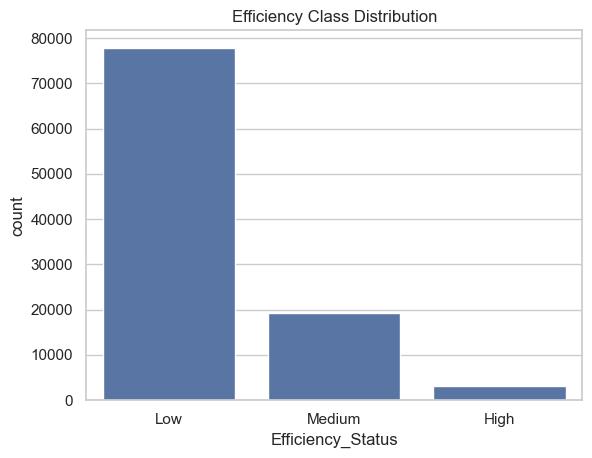

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Efficiency_Status", data=df)

plt.title("Efficiency Class Distribution")

plt.show()

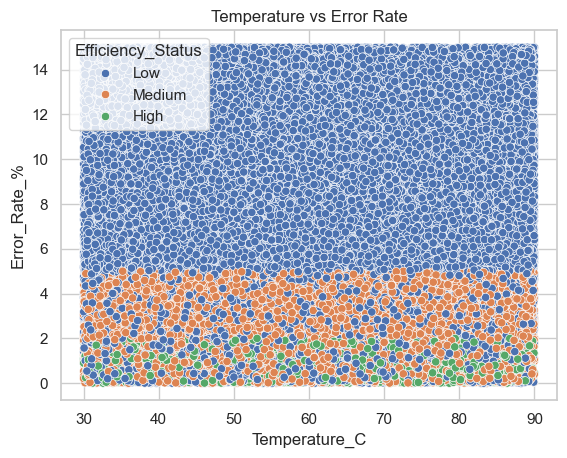

In [28]:
sns.scatterplot(
    x="Temperature_C",
    y="Error_Rate_%",
    hue="Efficiency_Status",
    data=df
)

plt.title("Temperature vs Error Rate")

plt.show()

<Axes: xlabel='Vibration_Hz', ylabel='Predictive_Maintenance_Score'>

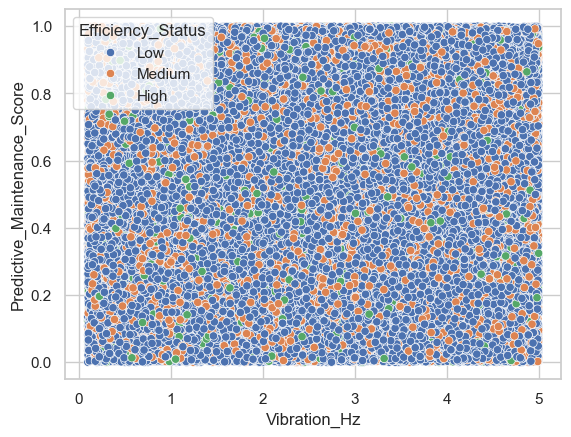

In [29]:
sns.scatterplot(
    x="Vibration_Hz",
    y="Predictive_Maintenance_Score",
    hue="Efficiency_Status",
    data=df
)

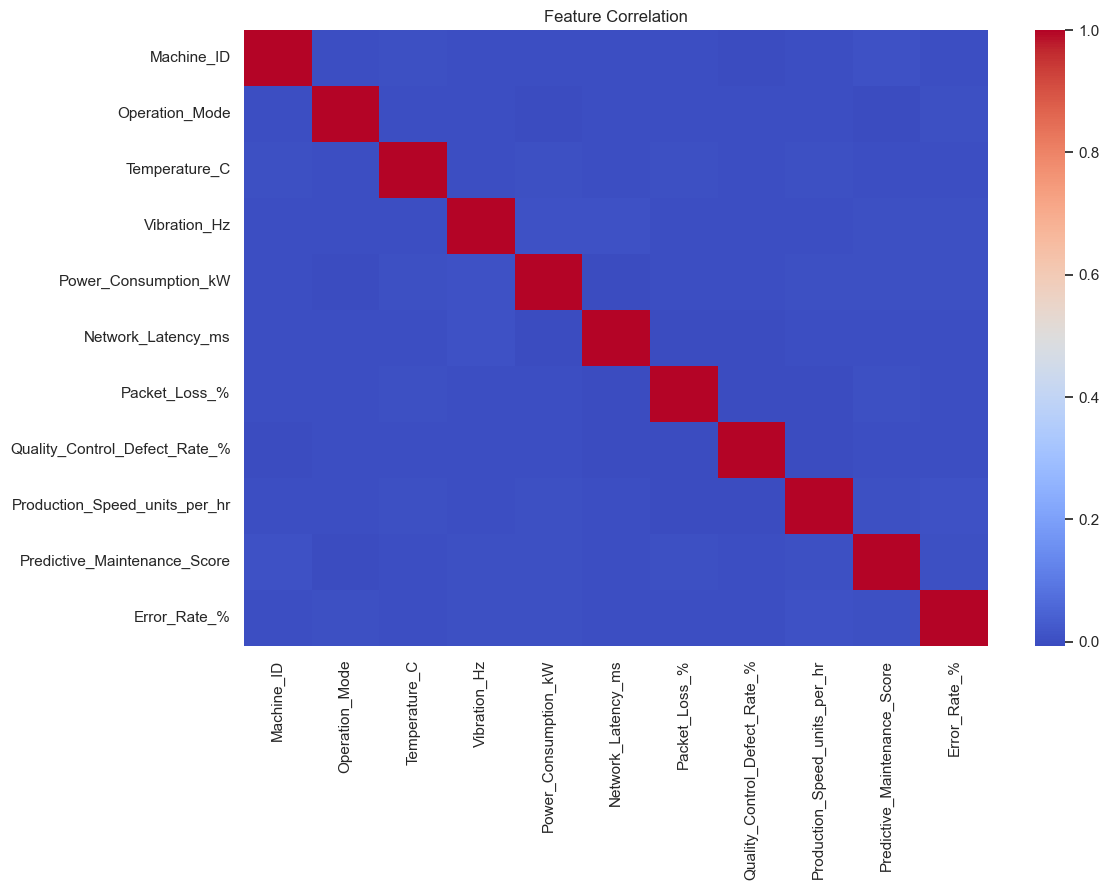

In [31]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(corr, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

In [32]:
df["Error_Output_Ratio"] = (
    df["Error_Rate_%"] /
    df["Production_Speed_units_per_hr"]
)

In [33]:
df["Network_Reliability"] = (
    100 - df["Packet_Loss_%"] -
    df["Network_Latency_ms"]/10
)

In [34]:
df["Energy_Efficiency"] = (
    df["Production_Speed_units_per_hr"] /
    df["Power_Consumption_kW"]
)

In [36]:
X = df.drop(
    ["Efficiency_Status","Date","Timestamp","Datetime"],
    axis=1
)

y = df["Efficiency_Status"]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [49]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=200)

log_model.fit(X_train, y_train)

pred = log_model.predict(X_test)

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

        High       0.90      0.84      0.87       625
         Low       0.95      0.96      0.95     15464
      Medium       0.81      0.76      0.79      3911

    accuracy                           0.92     20000
   macro avg       0.88      0.86      0.87     20000
weighted avg       0.92      0.92      0.92     20000



In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [51]:

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       625
         Low       1.00      1.00      1.00     15464
      Medium       1.00      1.00      1.00      3911

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Efficiency_Status"] = le.fit_transform(df["Efficiency_Status"])
print(df["Efficiency_Status"].unique())

[1 2 0]


In [55]:
X = df.drop(["Efficiency_Status","Date","Timestamp","Datetime"], axis=1)

y = df["Efficiency_Status"]

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

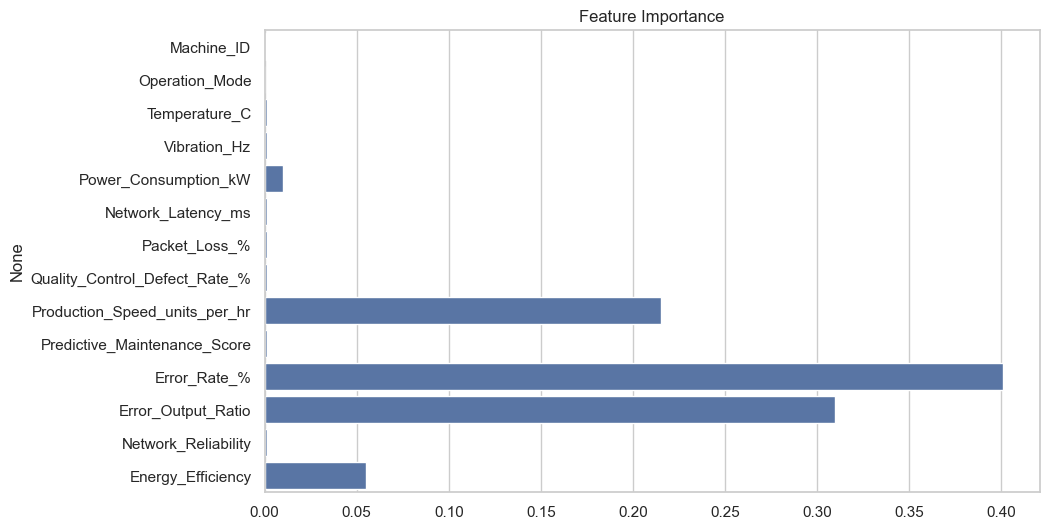

In [58]:
importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))

sns.barplot(x=importance, y=features)

plt.title("Feature Importance")

plt.show()

In [ ]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(rf, "models/efficiency_model.pkl")

['models/efficiency_model.pkl']

## Insights

1. The distribution of manufacturing efficiency shows...
2. There are some features that are highly correlated with efficiency...
3. Missing values need to be addressed before model training...

Further analysis can be conducted based on these findings.